In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('benchmark/all_results.csv')

# Classify circuit type from circuit name
def classify(name):
    if 'gausssum' in name: return 'Gaussian Sum'
    if 'treesum' in name: return 'Tree Sum'
    if 'seqsum' in name: return 'Sequential Sum'
    if 'bitonic' in name: return 'Bitonic Sort'
    if 'select' in name: return 'Selection'
    if 'treemech' in name: return 'Tree Mechanism'
    if 'distincthist' in name: return 'Distinct Elements (Histogram)'
    if 'distinct' in name: return 'Distinct Elements'
    if 'lcb' in name: return 'Linear Contextual Bandits'
    return 'Other'

df['circuit_type'] = df['circuit'].apply(classify)

# All costs come from actual measured benchmark data in the CSV:
#   garble_time_us, ot_are_time_us, boundary_time_us  (microseconds)
#   garbled_table_bytes, ot_are_bytes, boundary_bytes  (bytes)
print(f'Loaded {len(df)} rows')
print(f'Experiments: {sorted(df["experiment"].unique())}')
print(f'Circuits: {sorted(df["circuit_type"].unique())}')
print(f'N values: {sorted(df["n_clients"].unique())}')
print(f'Balanced values: {sorted(df["balanced"].unique())}')
df.head()

Loaded 480 rows
Experiments: ['net_bitonic_N16_bal', 'net_bitonic_N16_unbal', 'net_bitonic_N2_bal', 'net_bitonic_N2_unbal', 'net_bitonic_N4_bal', 'net_bitonic_N4_unbal', 'net_bitonic_N8_bal', 'net_bitonic_N8_unbal', 'net_distinct_N16_bal', 'net_distinct_N16_unbal', 'net_distinct_N2_bal', 'net_distinct_N2_unbal', 'net_distinct_N4_bal', 'net_distinct_N4_unbal', 'net_distinct_N8_bal', 'net_distinct_N8_unbal', 'net_distincthist_N16_bal', 'net_distincthist_N16_unbal', 'net_distincthist_N2_bal', 'net_distincthist_N2_unbal', 'net_distincthist_N4_bal', 'net_distincthist_N4_unbal', 'net_distincthist_N8_bal', 'net_distincthist_N8_unbal', 'net_gausssum_N16_bal', 'net_gausssum_N16_unbal', 'net_gausssum_N2_bal', 'net_gausssum_N2_unbal', 'net_gausssum_N4_bal', 'net_gausssum_N4_unbal', 'net_gausssum_N8_bal', 'net_gausssum_N8_unbal', 'net_lcb_N16_bal', 'net_lcb_N16_unbal', 'net_lcb_N2_bal', 'net_lcb_N2_unbal', 'net_lcb_N4_bal', 'net_lcb_N4_unbal', 'net_lcb_N8_bal', 'net_lcb_N8_unbal', 'net_select_N16_

,experiment,n_clients,circuit,circuit_gates,bit_width,balanced,client_id,num_gates,num_and,num_inputs,...,num_boundary_out,garble_time_us,ot_are_time_us,boundary_time_us,total_time_us,garbled_table_bytes,ot_are_bytes,boundary_bytes,total_bytes,circuit_type
0,net_treesum_N2_bal,2,treesum,47,8,1,0,24,9,8,...,12,3.625,80678.000,0.0,80681.600,288,245760,0,246048,Tree Sum
1,net_treesum_N2_bal,2,treesum,47,8,1,1,23,6,8,...,0,11.209,77933.500,189264.0,267209.000,192,245760,368640,614592,Tree Sum
2,net_treesum_N2_unbal,2,treesum,47,8,0,0,47,15,16,...,0,9.375,160495.000,0.0,160504.000,480,491520,0,492000,Tree Sum
3,net_treesum_N2_unbal,2,treesum,47,8,0,1,0,0,0,...,0,0.042,0.042,0.0,0.084,0,0,0,0,Tree Sum
4,net_treesum_N4_bal,4,treesum,127,8,1,0,32,13,8,...,10,7.500,86171.500,0.0,86179.000,416,245760,0,246176,Tree Sum


In [46]:
# Aggregate per experiment: bal vs unbal
def parse_mode(exp):
    if exp.endswith('_unbal'):  return 'unbal'
    if exp.endswith('_bal'):    return 'bal'
    return 'bal'
df['mode'] = df['experiment'].apply(parse_mode)

def compute_costs(group):
    n = group['n_clients'].iloc[0]
    circuit = group['circuit'].iloc[0]
    balanced = group['balanced'].iloc[0]
    gates = group['circuit_gates'].iloc[0]
    ct = group['circuit_type'].iloc[0]
    mode = group['mode'].iloc[0]

    total_and = group['num_and'].sum()
    total_inputs = group['num_inputs'].sum()
    total_boundary = group['num_boundary_in'].sum()

    avg_comp_ms = group['total_time_us'].mean() / 1000.0
    max_comp_ms = group['total_time_us'].max() / 1000.0
    avg_comm_KB = group['total_bytes'].mean() / 1024.0
    max_comm_KB = group['total_bytes'].max() / 1024.0

    return pd.Series({
        'n_clients': n, 'circuit': circuit, 'circuit_gates': gates,
        'balanced': balanced, 'circuit_type': ct, 'mode': mode,
        'total_and': total_and, 'total_inputs': total_inputs,
        'total_boundary': total_boundary,
        'avg_comp_ms': avg_comp_ms, 'max_comp_ms': max_comp_ms,
        'avg_comm_KB': avg_comm_KB, 'max_comm_KB': max_comm_KB,
    })

runs = df.groupby('experiment').apply(compute_costs).reset_index()

unbal_base = runs[runs['mode'] == 'unbal'].drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
unbal_base = unbal_base.set_index(['circuit', 'n_clients'])[['max_comp_ms', 'max_comm_KB']]
unbal_base.columns = ['unbal_comp_ms', 'unbal_comm_KB']

bal_runs = runs[runs['mode'] == 'bal'].copy()
bal_runs = bal_runs.drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
bal_runs = bal_runs.join(unbal_base, on=['circuit', 'n_clients'])
bal_runs['comp_speedup'] = bal_runs['unbal_comp_ms'] / bal_runs['avg_comp_ms']
bal_runs['comm_speedup'] = bal_runs['unbal_comm_KB'] / bal_runs['avg_comm_KB']

for ct in sorted(bal_runs['circuit_type'].unique()):
    sub = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
    if len(sub) == 0: continue
    print(f'--- {ct} ---')
    for _, row in sub.iterrows():
        print(f"  N={int(row['n_clients']):3d}  bal_avg={row['avg_comp_ms']:.1f}ms  "
              f"bal_max={row['max_comp_ms']:.1f}ms  unbal={row['unbal_comp_ms']:.1f}ms")
    print()


--- Bitonic Sort ---
  N=  2  bal_avg=169.7ms  bal_max=259.1ms  unbal=155.7ms
  N=  4  bal_avg=434.1ms  bal_max=668.6ms  unbal=311.1ms
  N=  8  bal_avg=1008.4ms  bal_max=1411.0ms  unbal=626.7ms
  N= 16  bal_avg=1721.2ms  bal_max=2309.1ms  unbal=1263.0ms

--- Distinct Elements ---
  N=  2  bal_avg=238.7ms  bal_max=357.8ms  unbal=233.3ms
  N=  4  bal_avg=476.1ms  bal_max=625.4ms  unbal=390.5ms
  N=  8  bal_avg=850.3ms  bal_max=1091.2ms  unbal=705.2ms
  N= 16  bal_avg=1770.5ms  bal_max=2252.7ms  unbal=1396.8ms

--- Distinct Elements (Histogram) ---
  N=  2  bal_avg=3969.8ms  bal_max=7783.7ms  unbal=244.2ms
  N=  4  bal_avg=6743.0ms  bal_max=14740.1ms  unbal=417.2ms
  N=  8  bal_avg=6209.7ms  bal_max=14491.2ms  unbal=722.3ms
  N= 16  bal_avg=5733.4ms  bal_max=15263.2ms  unbal=1358.8ms

--- Gaussian Sum ---
  N=  2  bal_avg=185.4ms  bal_max=288.3ms  unbal=157.3ms
  N=  4  bal_avg=188.7ms  bal_max=313.7ms  unbal=312.4ms
  N=  8  bal_avg=236.8ms  bal_max=388.7ms  unbal=634.0ms
  N= 16  bal_av

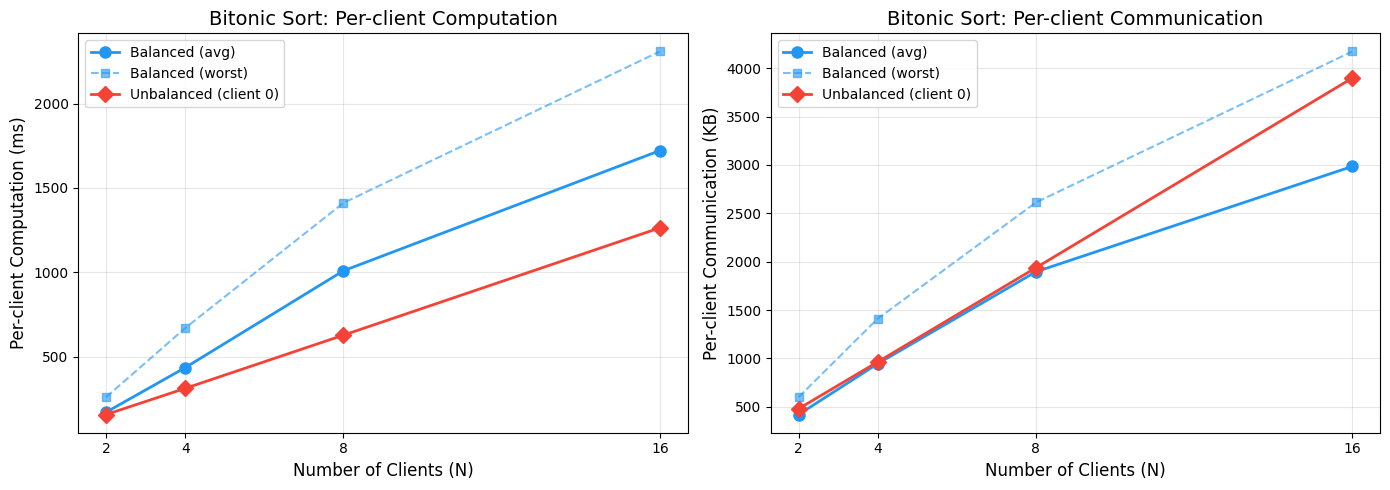

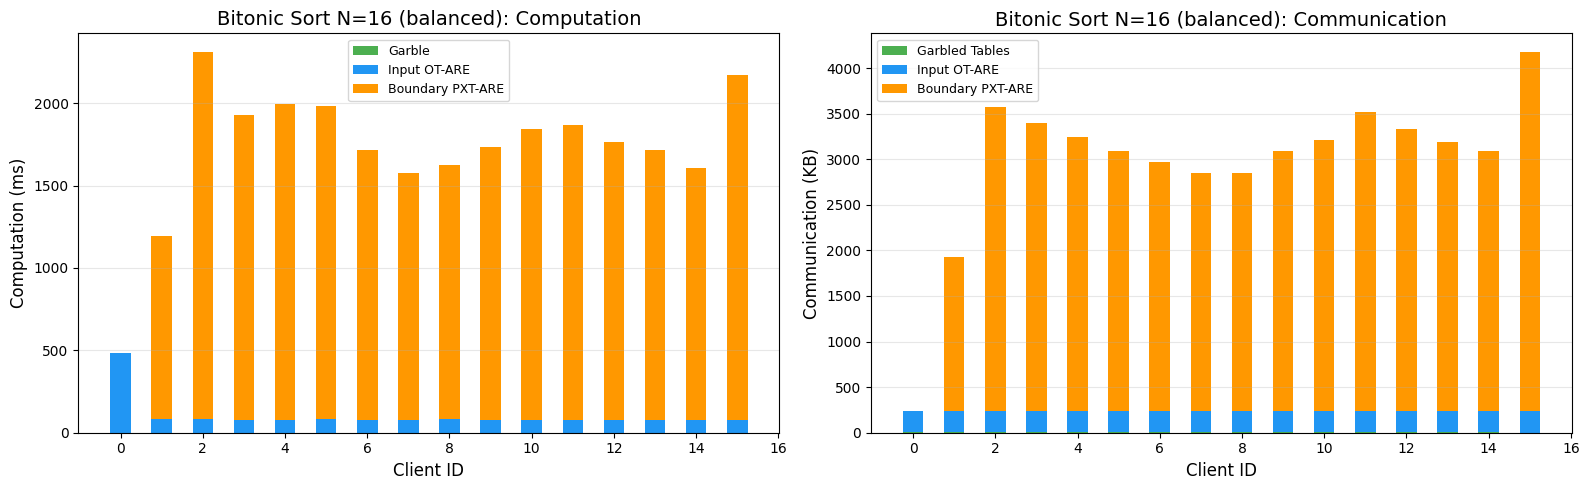

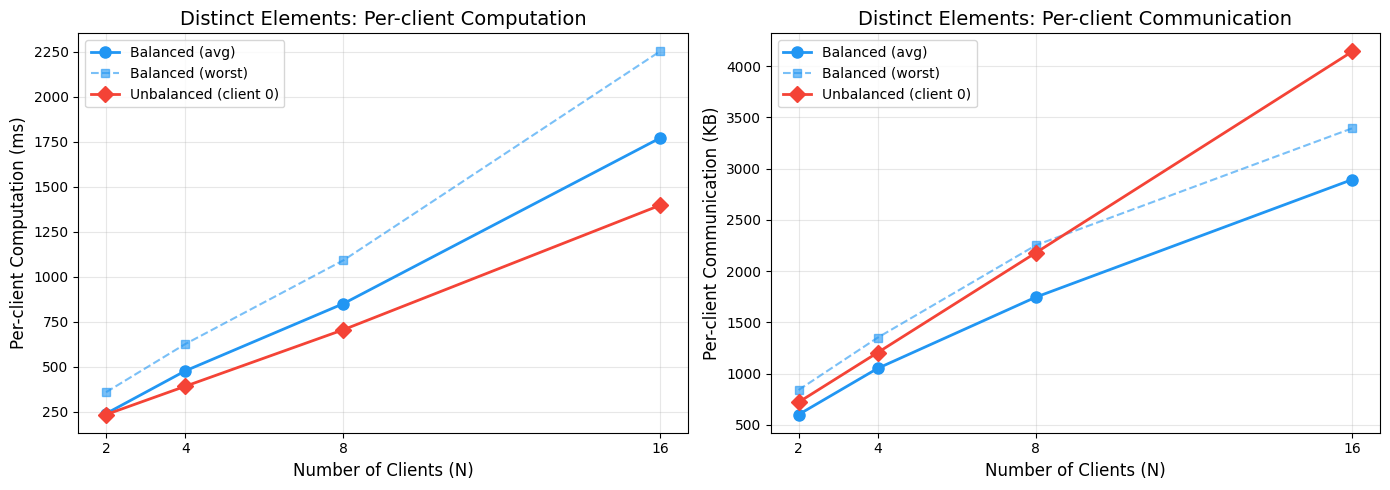

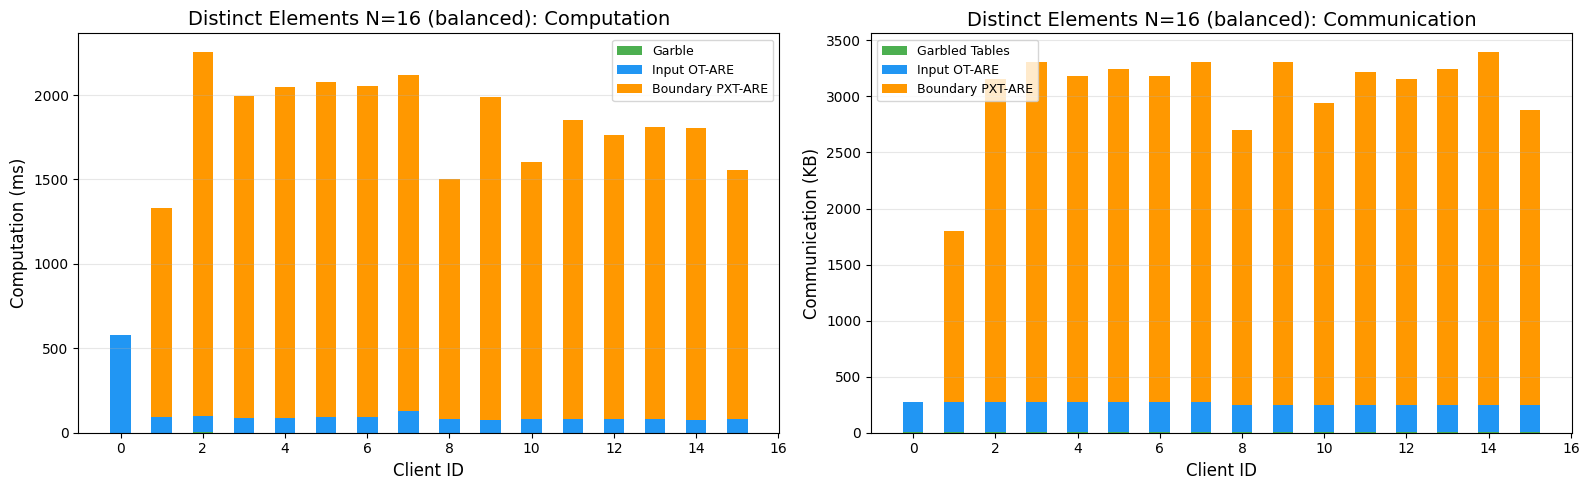

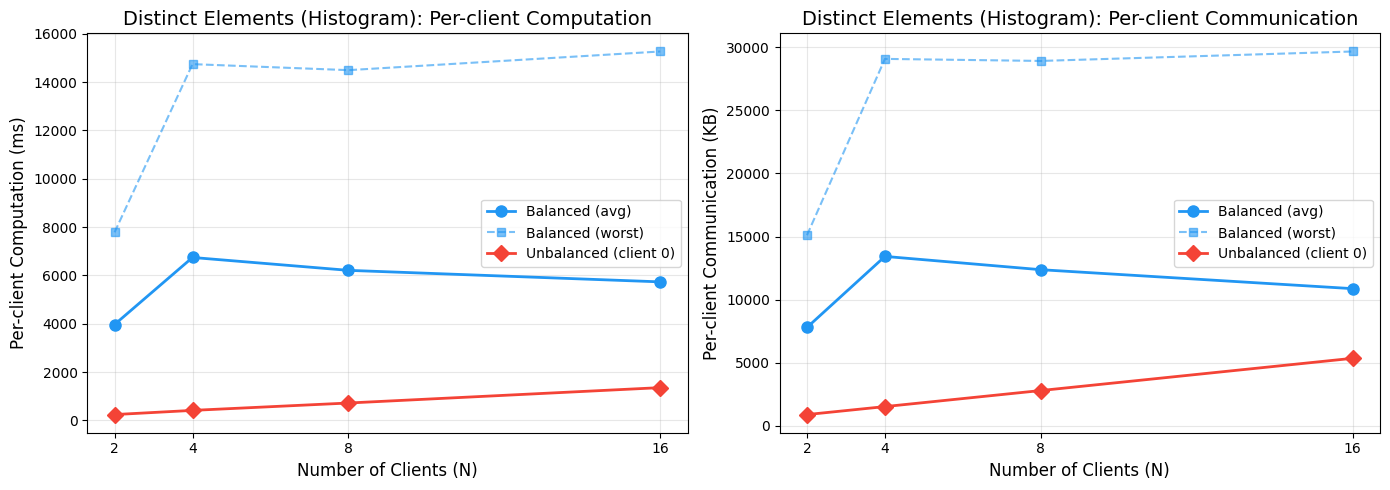

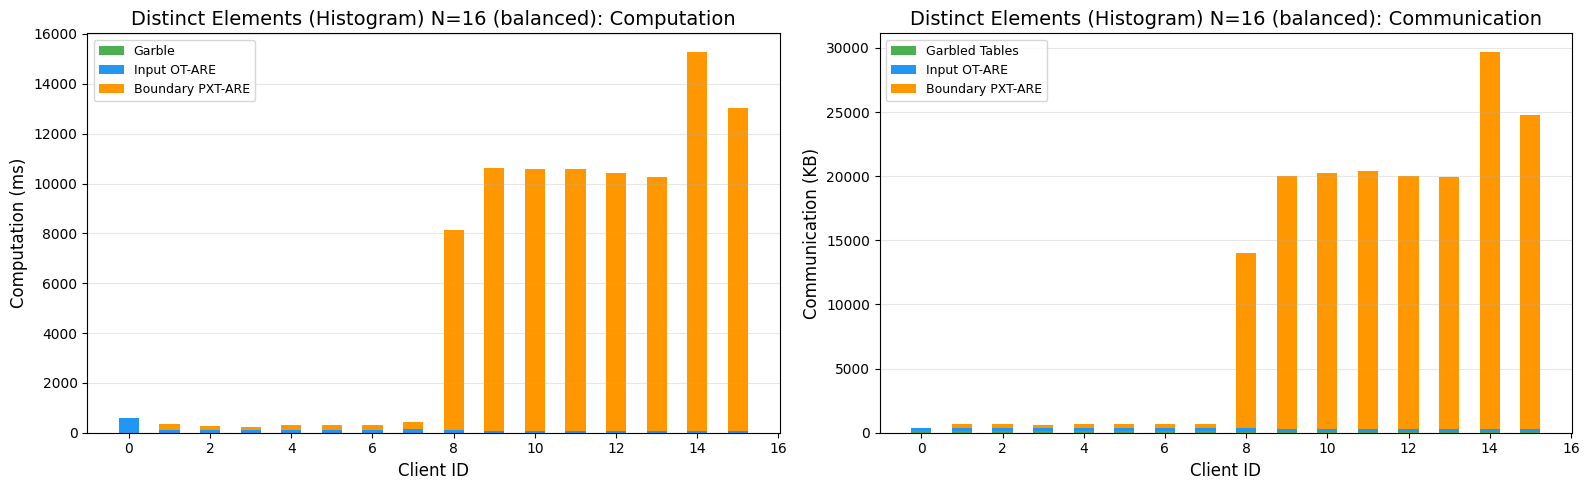

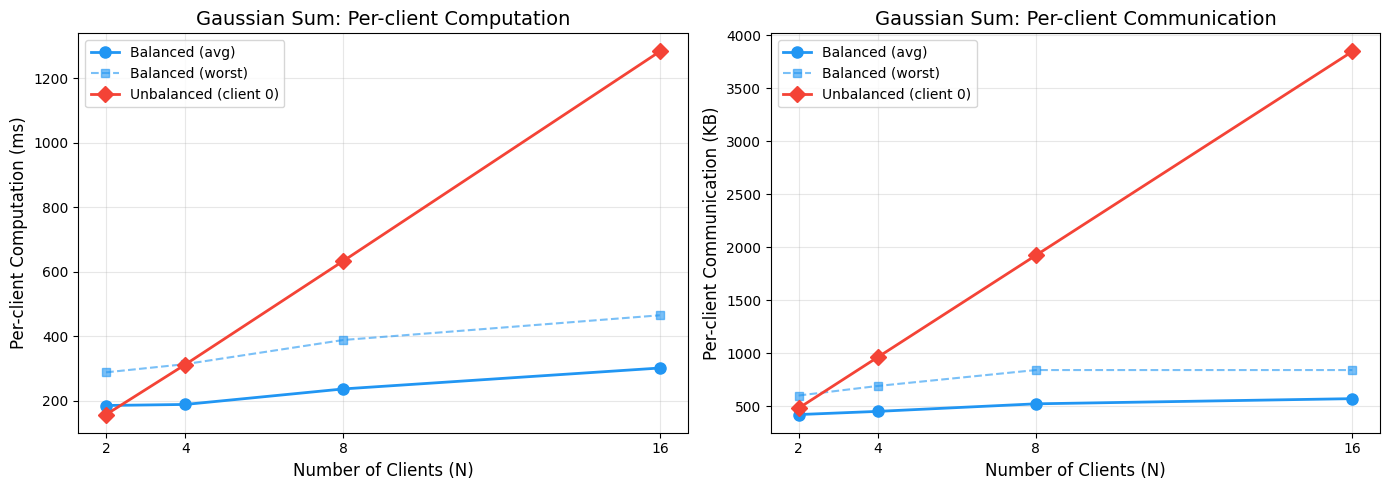

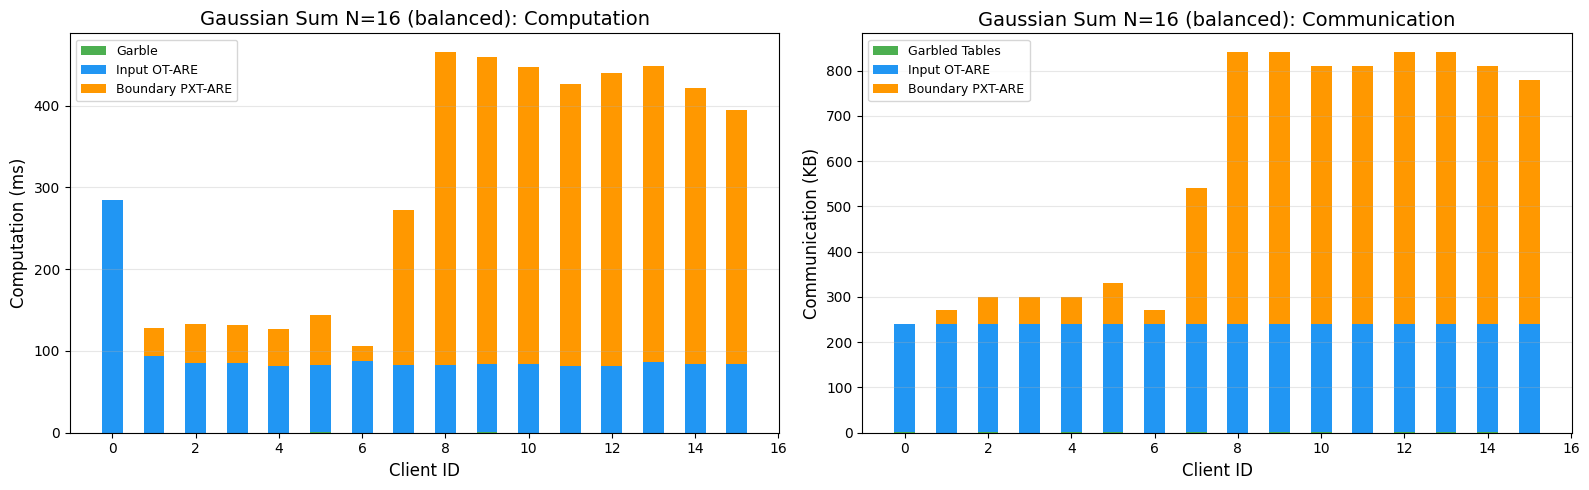

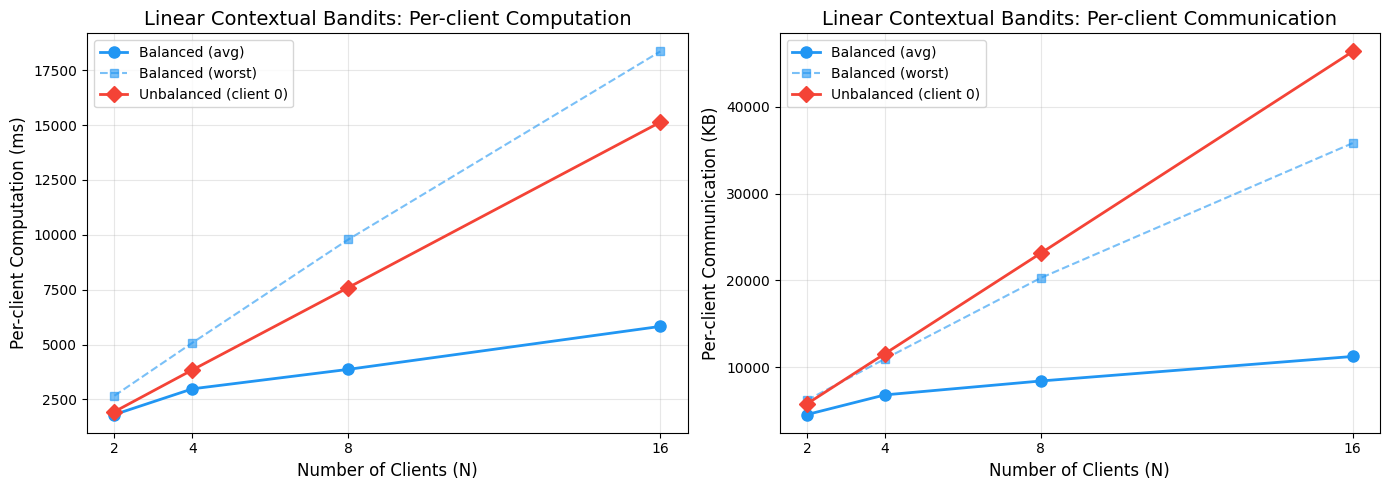

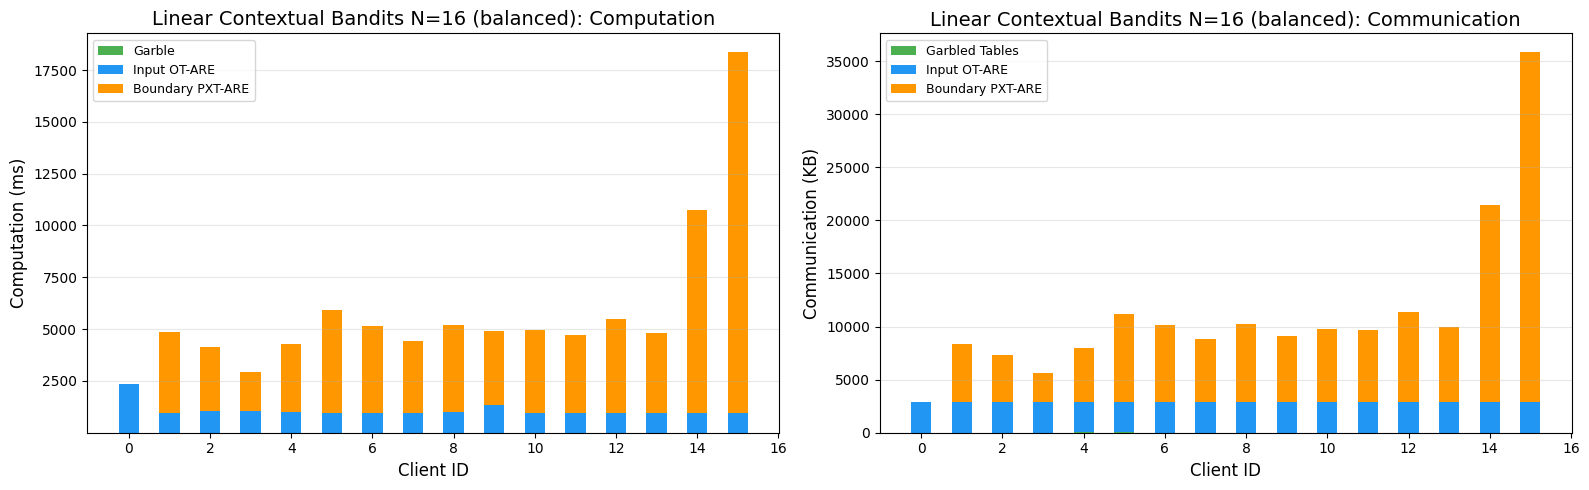

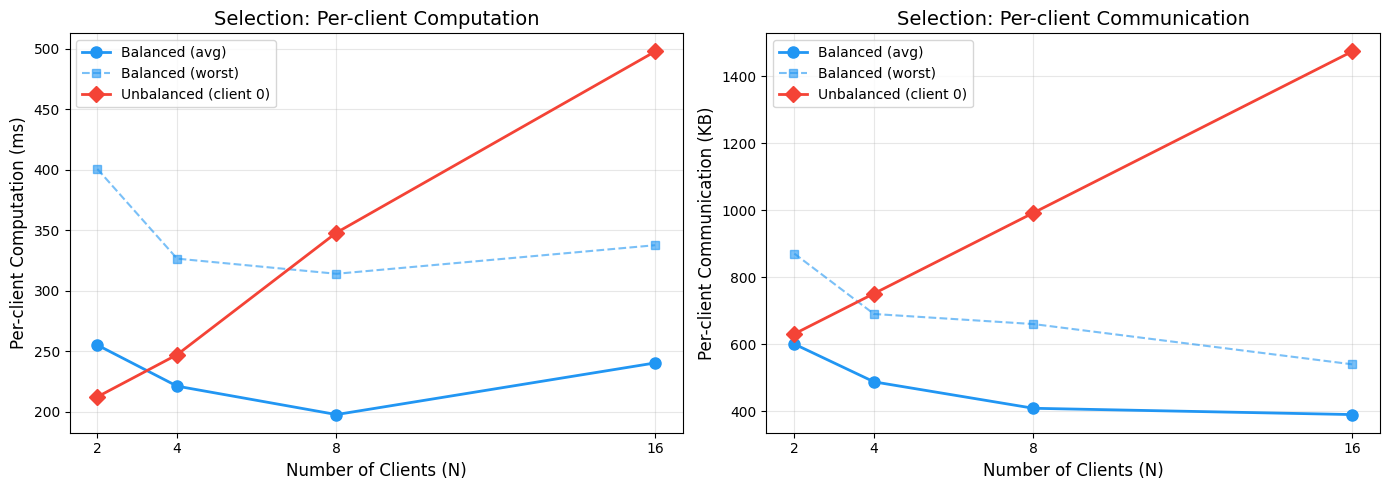

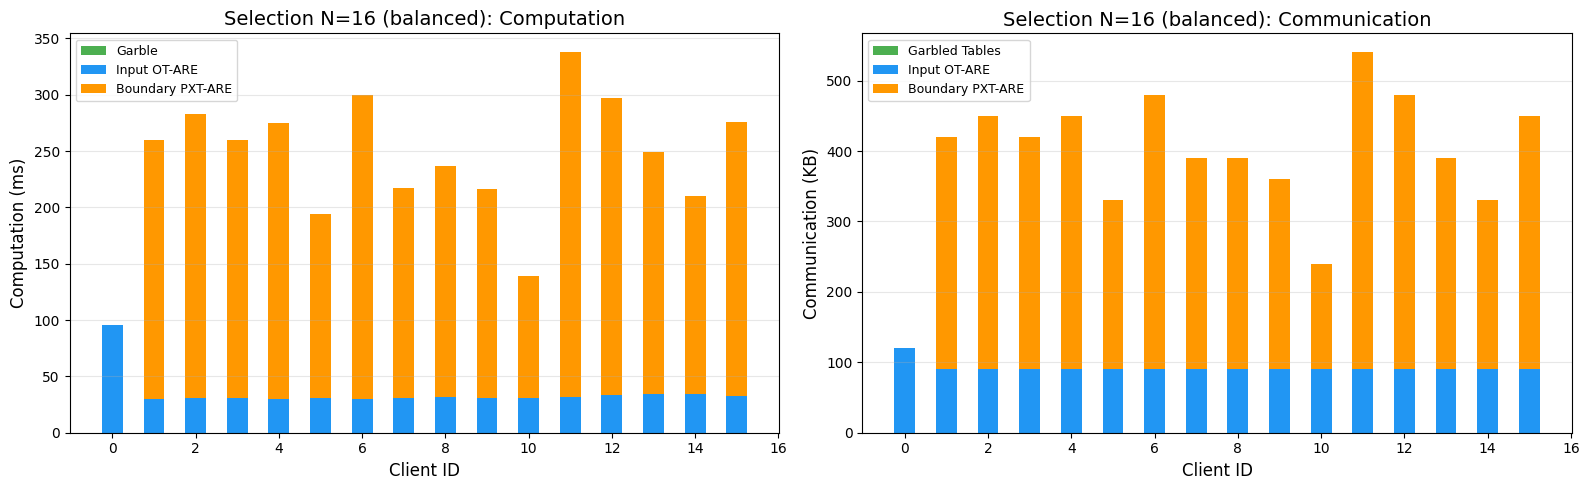

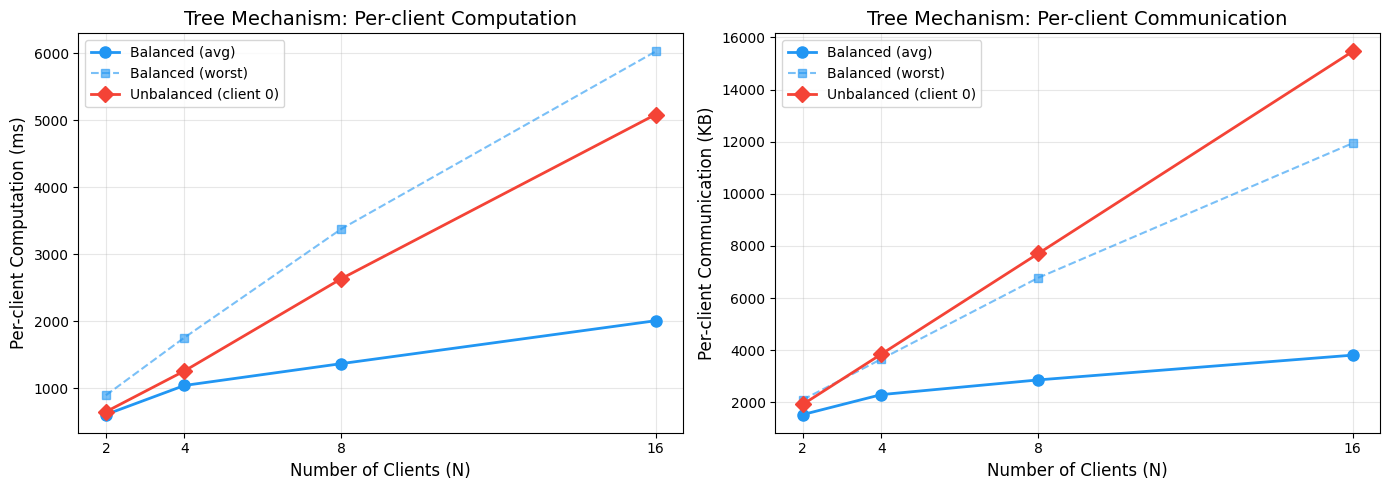

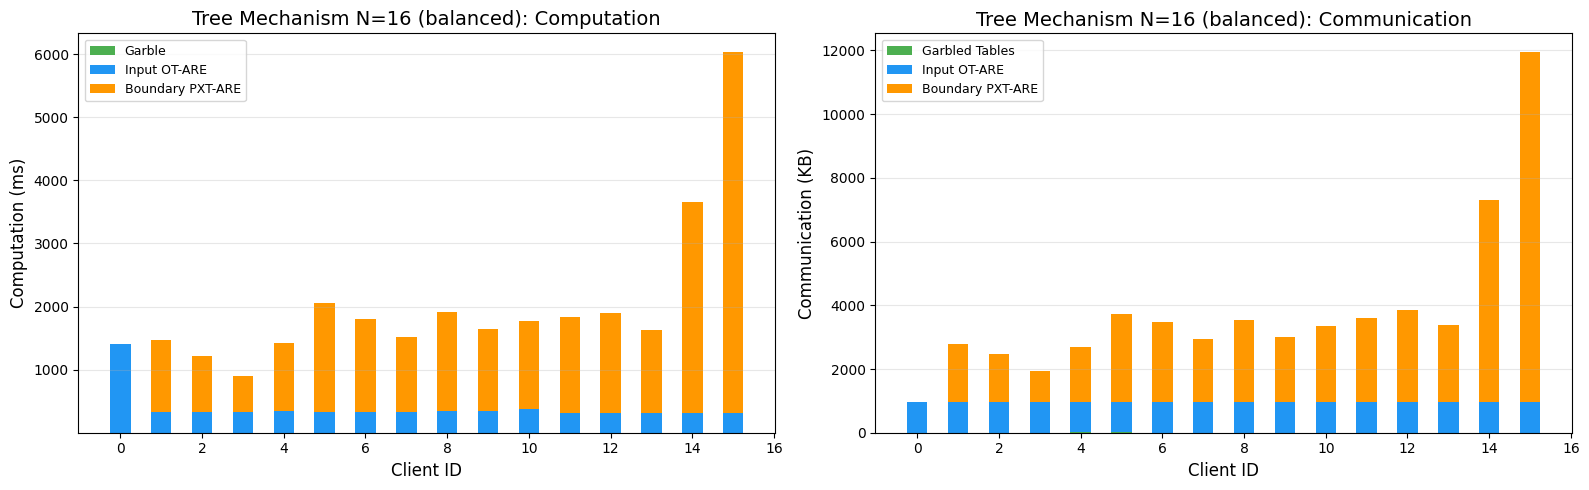

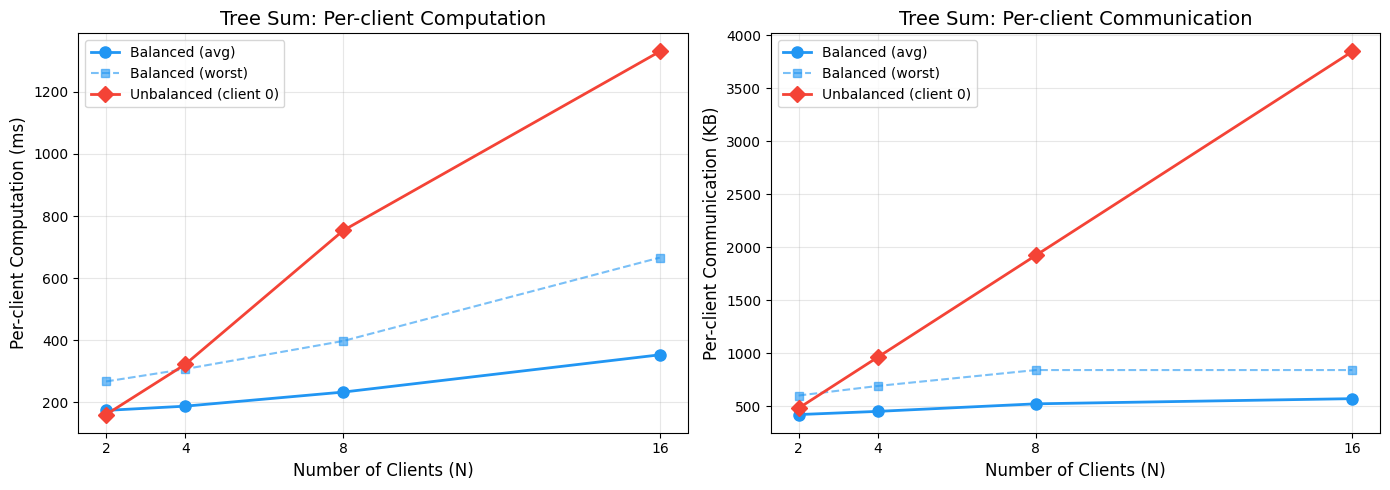

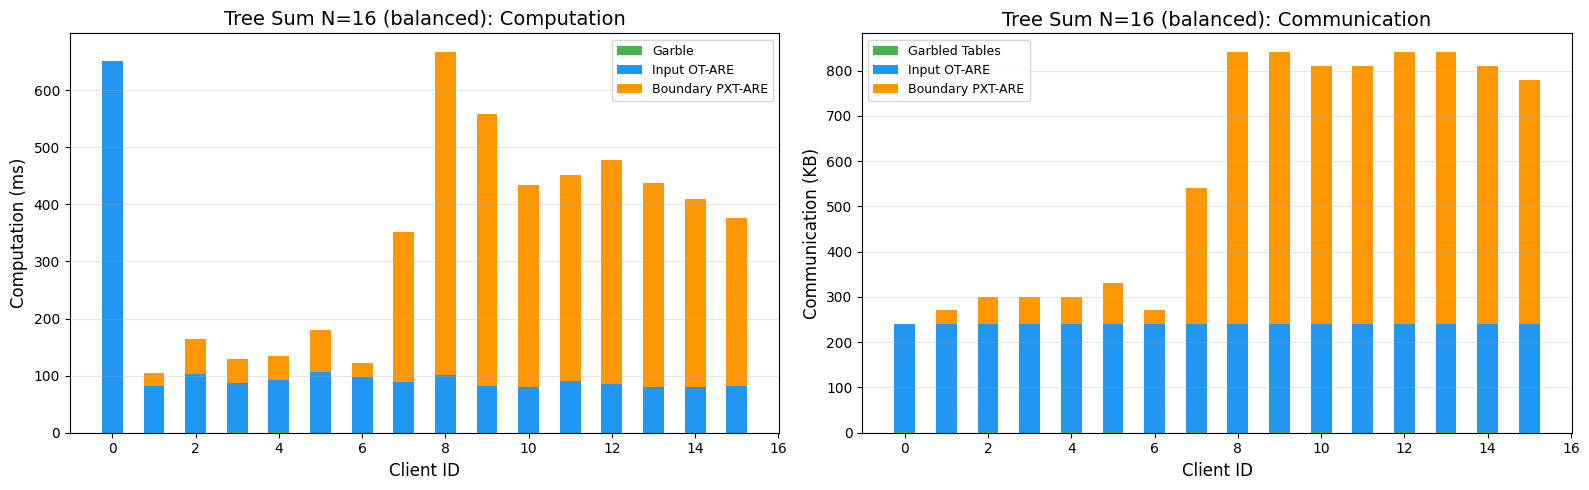

In [47]:
# ── Per-circuit plots: Balanced vs Unbalanced ───────────────
circuit_types = sorted(bal_runs['circuit_type'].unique())

for ct in circuit_types:
    ct_bal = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
    if len(ct_bal) == 0:
        continue

    # --- Plot A: Balanced vs Unbalanced ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = ct_bal['n_clients'].values

    axes[0].plot(x, ct_bal['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[0].plot(x, ct_bal['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst)')
    axes[0].plot(x, ct_bal['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title(f'{ct}: Per-client Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, ct_bal['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[1].plot(x, ct_bal['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst)')
    axes[1].plot(x, ct_bal['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title(f'{ct}: Per-client Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Plot B: Per-client breakdown (largest N) for balanced ---
    circ_key = ct_bal['circuit'].iloc[0]
    max_n = int(ct_bal['n_clients'].max())
    bal_exp = f'net_{circ_key}_N{max_n}_bal'
    sub = df[df['experiment'] == bal_exp].sort_values('client_id')
    if len(sub) == 0:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    xb = sub['client_id'].values
    w = 0.6 if max_n <= 8 else 0.5
    garble_t = sub['garble_time_us'].values / 1000.0
    input_t = sub['ot_are_time_us'].values / 1000.0
    boundary_t = sub['boundary_time_us'].values / 1000.0
    axes[0].bar(xb, garble_t, w, label='Garble', color='#4CAF50')
    axes[0].bar(xb, input_t, w, bottom=garble_t, label='Input OT-ARE', color='#2196F3')
    axes[0].bar(xb, boundary_t, w, bottom=garble_t+input_t, label='Boundary PXT-ARE', color='#FF9800')
    axes[0].set_xlabel('Client ID', fontsize=12)
    axes[0].set_ylabel('Computation (ms)', fontsize=12)
    axes[0].set_title(f'{ct} N={max_n} (balanced): Computation', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')
    garble_c = sub['garbled_table_bytes'].values / 1024.0
    input_c = sub['ot_are_bytes'].values / 1024.0
    boundary_c = sub['boundary_bytes'].values / 1024.0
    axes[1].bar(xb, garble_c, w, label='Garbled Tables', color='#4CAF50')
    axes[1].bar(xb, input_c, w, bottom=garble_c, label='Input OT-ARE', color='#2196F3')
    axes[1].bar(xb, boundary_c, w, bottom=garble_c+input_c, label='Boundary PXT-ARE', color='#FF9800')
    axes[1].set_xlabel('Client ID', fontsize=12)
    axes[1].set_ylabel('Communication (KB)', fontsize=12)
    axes[1].set_title(f'{ct} N={max_n} (balanced): Communication', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Plot 4: All circuits — Balanced vs Unbalanced (overlay) ────────────
# If multiple circuit types exist, plot them all on one figure
circuit_types = sorted(bal_runs['circuit_type'].unique())
colors_ct = {'Sequential Sum': '#2196F3', 'Tree Sum': '#FF9800', 'Gaussian Sum': '#4CAF50',
             'Tree Mechanism': '#E91E63', 'Bitonic Sort': '#9C27B0', 'Selection': '#00BCD4',
             'Linear Contextual Bandits': '#795548', 'Distinct Elements': '#3F51B5'}
markers_ct = {'Sequential Sum': 'o', 'Tree Sum': 's', 'Gaussian Sum': 'D',
              'Tree Mechanism': '^', 'Bitonic Sort': 'v', 'Selection': 'p',
              'Linear Contextual Bandits': '*', 'Distinct Elements': 'X'}

if len(circuit_types) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ct in circuit_types:
        sub = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
        if len(sub) == 0: continue
        x = sub['n_clients'].values
        m = markers_ct.get(ct, 'o')
        c = colors_ct.get(ct, 'gray')
        axes[0].plot(x, sub['avg_comp_ms'], f'{m}-', color=c, linewidth=2, markersize=8, label=f'{ct} (bal avg)')
        axes[0].plot(x, sub['unbal_comp_ms'], f'{m}--', color=c, linewidth=1.5, markersize=6, alpha=0.5, label=f'{ct} (unbal)')
        axes[1].plot(x, sub['avg_comm_KB'], f'{m}-', color=c, linewidth=2, markersize=8, label=f'{ct} (bal avg)')
        axes[1].plot(x, sub['unbal_comm_KB'], f'{m}--', color=c, linewidth=1.5, markersize=6, alpha=0.5, label=f'{ct} (unbal)')

    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('All Circuits: Balanced vs Unbalanced Computation', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('All Circuits: Balanced vs Unbalanced Communication', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f'Only one circuit type ({circuit_types[0]}) available — see per-circuit plots above.')

In [ ]:
# ── Summary tables ───────────────────────────────────────────────────────

cols = ['n_clients', 'circuit', 'circuit_gates', 'total_and', 'total_inputs',
        'total_boundary', 'avg_comp_ms', 'max_comp_ms', 'unbal_comp_ms', 'comp_speedup',
        'avg_comm_KB', 'max_comm_KB', 'unbal_comm_KB', 'comm_speedup']

for ct in sorted(bal_runs['circuit_type'].unique()):
    sub = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
    if len(sub) == 0:
        print(f'=== {ct} === (no data)')
        continue
    print(f'=== {ct} ===')
    display_cols = [c for c in cols if c in sub.columns]
    display_df = sub[display_cols].copy()
    for c in display_df.columns:
        if display_df[c].dtype == float:
            display_df[c] = display_df[c].round(1)
    display(display_df)
    print()